# Hybrid Gait 研究進度展示

這份 Notebook 是目前研究成果的快速入口。目前包含 **Day 1–2：offline planner architecture / data contracts**，以及 **Day 3–5 Step 0：既有 Leg Geometry API 盤點**；尚未開始 terrain gap、collision 或 `query_contact()` 本體。

目前已完成：

- 已知 structured terrain 的資料表示
- semantic multi-rim contact state / candidate
- offline planning request（initial state、完整 path、constraints）
- 四腳同步 full-trajectory 資料格式
- deterministic `trajectory.csv` exporter

> 下方 trajectory 是用來展示資料流與輸出格式的 **synthetic contract demo**，不能視為 `query_contact()` 或 rolling feasibility 的研究結果。

## 1. 載入目前的 planning contracts

In [1]:
from pathlib import Path
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np

# 可從 LegWheel root、hybrid_note/notes 或 Jupyter 啟動目錄執行。
search_root = Path.cwd().resolve()
project_root = next(
    (path for path in (search_root, *search_root.parents) if (path / 'legwheel').is_dir()),
    None,
)
if project_root is None:
    raise RuntimeError('找不到 LegWheel project root；請從專案內啟動此 Notebook。')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from legwheel.planners.hybrid import (
    ContactCandidate,
    GaitConstraints,
    HybridPlanningRequest,
    HybridTrajectory,
    InitialRobotState,
    MotionMode,
    RectangularObstacle,
    RimId,
    TerrainProfile,
    TraversalGoal,
    write_trajectory_csv,
)

print(f'Project root: {project_root}')
print('Hybrid planning contracts imported successfully.')

Project root: /home/chang/corgi_ws/icra hybrid/LegWheel
Hybrid planning contracts imported successfully.


## 2. 建立 known terrain 與完整 offline planning request

Planner 執行前會收到完整 terrain、initial robot state、goal/path 與 gait constraints。所有 public positions 都使用 world frame `{W}`：`+x` 前、`+y` 左、`+z` 上。

In [2]:
obstacle = RectangularObstacle(
    surface_id='box_1',
    min_xy_world_m=[0.40, -0.20],
    max_xy_world_m=[0.60, 0.20],
    height_m=0.05,
)
terrain = TerrainProfile(ground_height_m=0.0, obstacles=[obstacle])
initial_state = InitialRobotState(
    body_position_world_m=[0.0, 0.0, 0.30],
    body_rpy_rad=[0.0, 0.0, 0.0],
    joint_position_rad=np.zeros((4, 3)),
)
goal = TraversalGoal(
    body_path_world_m=[
        [0.0, 0.0, 0.30],
        [0.5, 0.0, 0.30],
        [1.0, 0.0, 0.30],
    ]
)
constraints = GaitConstraints(
    minimum_clearance_m=0.02,
    minimum_stability_margin_m=0.01,
    sample_period_s=0.02,
)
request = HybridPlanningRequest(terrain, initial_state, goal, constraints)
request

HybridPlanningRequest(terrain=TerrainProfile(ground_height_m=0.0, obstacles=(RectangularObstacle(surface_id='box_1', min_xy_world_m=array([ 0.4, -0.2]), max_xy_world_m=array([0.6, 0.2]), height_m=0.05),), ground_surface_id='ground'), initial_state=InitialRobotState(body_position_world_m=array([0. , 0. , 0.3]), body_rpy_rad=array([0., 0., 0.]), joint_position_rad=array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])), goal=TraversalGoal(body_path_world_m=array([[0. , 0. , 0.3],
       [0.5, 0. , 0.3],
       [1. , 0. , 0.3]])), constraints=GaitConstraints(minimum_clearance_m=0.02, minimum_stability_margin_m=0.01, sample_period_s=0.02, maximum_swing_count=None))

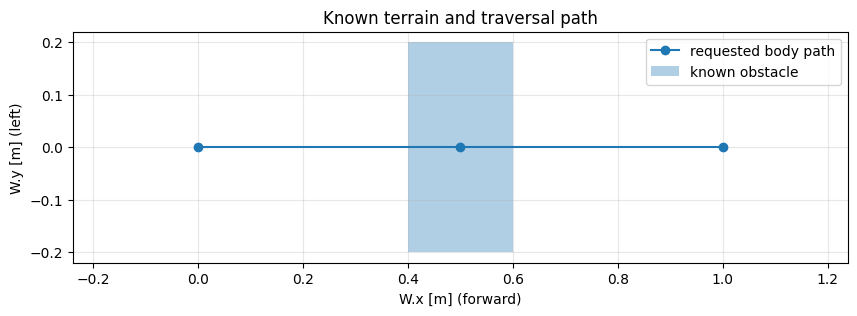

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
path = request.goal.body_path_world_m
ax.plot(path[:, 0], path[:, 1], 'o-', label='requested body path')
box = request.terrain.obstacles[0]
width, depth = box.max_xy_world_m - box.min_xy_world_m
ax.add_patch(plt.Rectangle(box.min_xy_world_m, width, depth, alpha=0.35, label='known obstacle'))
ax.set(xlabel='W.x [m] (forward)', ylabel='W.y [m] (left)', title='Known terrain and traversal path')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend();

## 3. Contact query 未來要產生的資料

以下只展示 `ContactCandidate` 的介面。Day 3–5 的 `query_contact()` 將負責從 leg pose 與 terrain 幾何真正計算這些數值。

In [4]:
example_candidate = ContactCandidate(
    rim=RimId.FOOT,
    alpha_rad=0.0,
    point_world_m=[0.45, 0.18, 0.05],
    terrain_gap_m=0.0,
    edge_margin_m=0.05,
    collision_free=True,
    terrain_surface_id='box_1',
)
example_candidate

ContactCandidate(rim=<RimId.FOOT: 'foot_rim'>, alpha_rad=0.0, point_world_m=array([0.45, 0.18, 0.05]), terrain_gap_m=0.0, edge_margin_m=0.05, collision_free=True, terrain_surface_id='box_1')

## 4. 建立 synthetic full trajectory

這段建立一份格式正確的示範 trajectory。Leg 1 在中段進行 SWING，其餘時間／腳維持 ROLL，用來確認完整資料能被同步保存與展示。

In [5]:
sample_count = 101
time_s = np.linspace(0.0, 2.0, sample_count)
body_pose = np.zeros((sample_count, 6))
body_pose[:, 0] = np.linspace(0.0, 1.0, sample_count)
body_pose[:, 2] = 0.30

joint_position = np.zeros((sample_count, 4, 3))
joint_position[:, :, 0] = np.deg2rad(45.0)
joint_position[:, :, 1] = 0.08 * np.sin(np.pi * time_s[:, None])

modes = [[MotionMode.ROLL for _ in range(4)] for _ in range(sample_count)]
contact_active = np.ones((sample_count, 4), dtype=bool)
swing_phase = np.zeros((sample_count, 4))
swing_slice = slice(35, 66)
for index in range(35, 66):
    modes[index][1] = MotionMode.SWING
contact_active[swing_slice, 1] = False
swing_phase[swing_slice, 1] = np.linspace(0.0, 1.0, 31)
joint_position[swing_slice, 1, 2] = np.deg2rad(8.0) * np.sin(np.pi * swing_phase[swing_slice, 1])

rims = [[RimId.FOOT for _ in range(4)] for _ in range(sample_count)]
alpha_rad = np.zeros((sample_count, 4))
footholds = np.zeros((sample_count, 4, 3))
footholds[:, :, 0] = body_pose[:, None, 0]
footholds[:, :, 1] = np.array([0.22, -0.22, -0.22, 0.22])
stability_margin = 0.025 - 0.008 * np.sin(np.pi * time_s / time_s[-1]) ** 2

trajectory = HybridTrajectory(
    time_s=time_s,
    body_pose_world=body_pose,
    joint_position_rad=joint_position,
    modes=modes,
    rims=rims,
    alpha_rad=alpha_rad,
    foothold_world_m=footholds,
    contact_active=contact_active,
    swing_phase=swing_phase,
    stability_margin_m=stability_margin,
)
print(f'Synchronized samples: {trajectory.sample_count}')
print(f'Duration: {trajectory.time_s[-1]:.2f} s')
print(f'Leg 1 swing samples: {sum(row[1] is MotionMode.SWING for row in trajectory.modes)}')

Synchronized samples: 101
Duration: 2.00 s
Leg 1 swing samples: 31


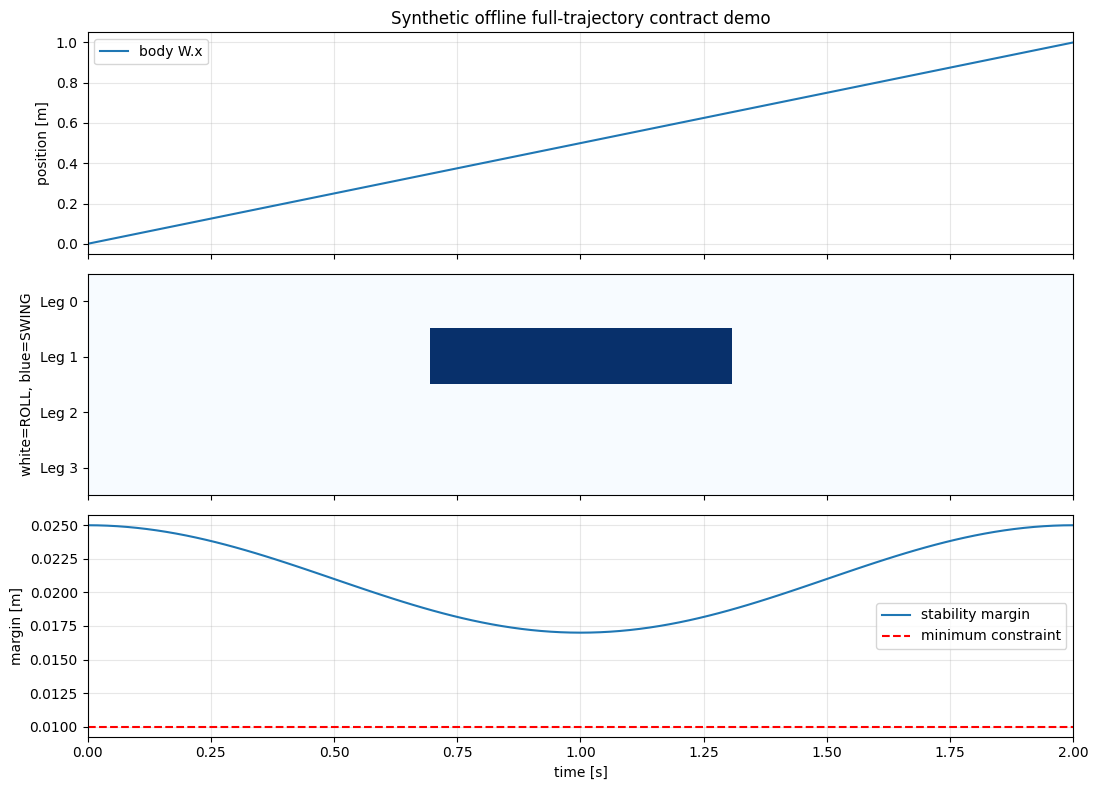

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(time_s, body_pose[:, 0], label='body W.x')
axes[0].set_ylabel('position [m]')
axes[0].set_title('Synthetic offline full-trajectory contract demo')
axes[0].legend()

mode_values = np.array([[mode is MotionMode.SWING for mode in row] for row in trajectory.modes]).T
axes[1].imshow(mode_values, aspect='auto', interpolation='nearest', extent=[time_s[0], time_s[-1], 3.5, -0.5], cmap='Blues')
axes[1].set_yticks(range(4), ['Leg 0', 'Leg 1', 'Leg 2', 'Leg 3'])
axes[1].set_ylabel('white=ROLL, blue=SWING')

axes[2].plot(time_s, stability_margin, label='stability margin')
axes[2].axhline(constraints.minimum_stability_margin_m, color='r', linestyle='--', label='minimum constraint')
axes[2].set(xlabel='time [s]', ylabel='margin [m]')
axes[2].legend()
for ax in (axes[0], axes[2]):
    ax.grid(True, alpha=0.3)
plt.tight_layout();

## 5. 匯出 deterministic trajectory CSV

預設寫入專案的 `hybrid_note/outputs/tables/hybrid_gait/`。這個 schema 預計由 simulation 與 real robot trajectory player 共用。

In [7]:
output_path = project_root / 'hybrid_note' / 'outputs' / 'tables' / 'hybrid_gait' / 'day1_2_contract_demo.csv'
write_trajectory_csv(trajectory, output_path)
print(f'CSV written to: {output_path}')
print(f'Rows including header: {len(output_path.read_text().splitlines())}')
print('First 12 columns:')
print(output_path.read_text().splitlines()[0].split(',')[:12])

CSV written to: /home/chang/corgi_ws/icra hybrid/LegWheel/hybrid_note/outputs/tables/hybrid_gait/day1_2_contract_demo.csv
Rows including header: 102
First 12 columns:
['time_s', 'body_x', 'body_y', 'body_z', 'body_roll', 'body_pitch', 'body_yaw', 'leg0_theta', 'leg0_beta', 'leg0_gamma', 'leg0_mode', 'leg0_rim']


## 6. Day 1–2 資料流總結

目前資料流已經固定：

```text
Known terrain + Initial state + Goal + Constraints
                         ↓
              Offline hybrid planner
                         ↓
            Synchronized HybridTrajectory
                         ↓
                   trajectory.csv
                         ↓
        Simulation / robot joint tracking
```

Day 1–2 的 public contract 固定使用 world frame 與 radians。下面從 Day 3–5 Step 0 開始盤點 legacy geometry，先找出可以直接 reuse 的資料與必須補上的 adapter。

# Day 3–5：Terrain-aware contact model

## 7. Step 0 — 既有 Leg Geometry API 盤點

本步驟**不實作 terrain query，也不重寫運動學**。目標是回答：輸入 `(theta, beta, gamma)` 後，現有程式能否提供所有 rim / linkage geometry，而不只是最低點。

驗收項目：rim center、endpoints、arc parameterization、foot/rim samples、`alpha` 定義、lowest point/region、frame conversion，以及 whole-leg collision 所需 linkage geometry。

In [8]:
import pandas as pd

from hybrid_note.scripts.kinematics.leg_geometry_inventory import (
    build_leg_geometry_inventory,
    plot_leg_geometry_inventory,
)

# Step 0 inspection pose；角度輸入沿用 kinematics 的 radians。
step0_theta_deg = 80.0
step0_beta_deg = -20.0
step0_gamma_deg = 10.0
step0_arc_samples = 121
step0_lateral_samples = 9

step0_inventory = build_leg_geometry_inventory(
    np.deg2rad(step0_theta_deg),
    np.deg2rad(step0_beta_deg),
    np.deg2rad(step0_gamma_deg),
    arc_samples=step0_arc_samples,
    lateral_samples=step0_lateral_samples,
)
print(f"Inspection pose: theta={step0_theta_deg:g}°, beta={step0_beta_deg:g}°, gamma={step0_gamma_deg:g}°")

Inspection pose: theta=80°, beta=-20°, gamma=10°


### 7.1 可直接 reuse 的 API 與缺口

`available now = partial/no` 不代表要在 Step 0 補完；它是後續 Step 2（座標統一）與 Step 5（whole-leg collision）要處理的明確清單。

Contact classification 沿用 `ContactMap_Note_ICRA.ipynb` 的 **F/L/R/N**。其中只有 F/L/R 是 planner 的 rim；N 只保留為診斷與 collision sampling 標籤。

In [9]:
rim_classification_table = pd.DataFrame(step0_inventory['rim_classification_rows'])
display(rim_classification_table.style.set_properties(**{'text-align': 'left'}))

capability_table = pd.DataFrame(step0_inventory['capability_rows'])
display(capability_table.style.set_properties(**{'text-align': 'left'}))

,state_id,semantic_class,valid_contact_rim,query_contact role
0,F,foot_rim,True,may produce ContactCandidate(rim=RimId.FOOT)
1,L,left_rim,True,may produce ContactCandidate(rim=RimId.LEFT)
2,R,right_rim,True,may produce ContactCandidate(rim=RimId.RIGHT)
3,N,non_contact_region,False,diagnostic/collision geometry only; never a contact candidate


,geometry/data,existing API,available now,frame / unit,Step 1+ action
0,2D linkage joints,"PlotLeg.forward(theta, beta); attributes A_l...H_extend_r",yes,"legacy leg plane (x, y_height), theta/beta in rad",reuse; wrap in a stable geometry result
1,named rim centers + endpoints,PlotLeg.leg_shape..arc[1],yes,"legacy leg plane, metre; endpoints implicit in arc limits",expose as numeric arrays (not Matplotlib objects)
2,3 physically contactable tyre surfaces / samples,sample_contact_geometry_points[_3d](...),yes,"2D leg plane or display-like 3D, metre",map foot/left/right tyre to F/L/R and the open upper gap to N
3,global rim parameter alpha,"LegModel.rim_point(alpha, w)",partial,alpha is degree; w is metre; 0 deg is foot-rim centre,add explicit deg-to-rad semantic adapter
4,per-arc geometric angle,surface_records[*].arc_angle_deg,yes,degree about each individual arc centre,do not treat this value as global contact alpha
5,lowest point / lowest region,compute_ground_contact[_pose_3d](...),yes,2D y_min or display-like 3D z_min,reuse only as flat-ground regression oracle
6,3D body-frame contact point,CorgiLegKinematics.forward_kinematics(...),yes,"body frame {B}, metre; alpha input is degree",use for the authoritative body/module transform
7,3D linkage points,CorgiLegKinematics.get_joint_positions(...),partial,"body frame {B}, metre; returns O...G only",extend if collision tests require H/I/J/rim centres
8,world-frame geometry,none in the sampled-contact helpers,no,"public planner requires {W}: +x forward, +y left, +z up",Step 2 must apply T_WB/T_WH explicitly
9,whole-linkage collision surface,PlotLeg bars/joints are drawable primitives,partial,legacy leg plane,expose numeric segments/circles before Step 5


### 7.2 Physical tyre surfaces 與 F/L/R/N 分類

依最新版 `ContactMap_Note_ICRA.ipynb`，contact geometry 只取 3 條實體 tyre arcs：`foot_rim / upper_tyre_l / upper_tyre_r`；structural rims 不納入 contact samples。它們映射成 `foot_rim / left_rim / right_rim`，而兩個 upper tyre 朝向 open gap 的邊界端點標為 `non_contact_region`。下表的 `arc_angle_*_deg` 是每個圓弧相對自身 center 的幾何角，不等於 planner 的全域 `alpha_rad`。

In [10]:
surface_table = pd.DataFrame(step0_inventory['surface_summary'])
numeric_columns = [column for column in surface_table if column.endswith(('_m', '_deg'))]
display(surface_table.style.format({column: '{:.5f}' for column in numeric_columns}))
print(f"Named rim surfaces: {len(surface_table)}")
print(f"2D sampled geometry points (including H_L/H_R/O references): {len(step0_inventory['contact_2d']['surface_points'])}")
print(f"3D sampled rim-surface points: {len(step0_inventory['contact_3d']['surface_points'])}")

,surface_name,semantic_states,sample_count,center_x_m,center_y_m,endpoint_0_x_m,endpoint_0_y_m,endpoint_1_x_m,endpoint_1_y_m,arc_angle_0_deg,arc_angle_1_deg
0,foot_rim,foot_rim,121,-0.03785,-0.10399,-0.16342,-0.17649,0.01174,-0.24025,-150.00000,-70.00000
1,upper_tyre_l,"left_rim, non_contact_region",121,-0.03560,-0.03602,-0.06957,0.10371,-0.09940,-0.16489,103.66271,243.66271
2,upper_tyre_r,"non_contact_region, right_rim",121,0.00412,-0.05048,-0.02984,-0.19021,0.11996,0.03473,-103.66271,36.33729


Named rim surfaces: 3
2D sampled geometry points (including H_L/H_R/O references): 366
3D sampled rim-surface points: 3267


### 7.3 幾何與 lowest-region 的關係

彩色幾何是 query 後續可以使用的**完整 rim samples**；紅色只是在 flat-ground 假設下，由全體 samples 選出的 lowest region。3D 圖目前是 contact-map helper 使用的 local/display-like frame，還不是含 body pose 的 world frame。

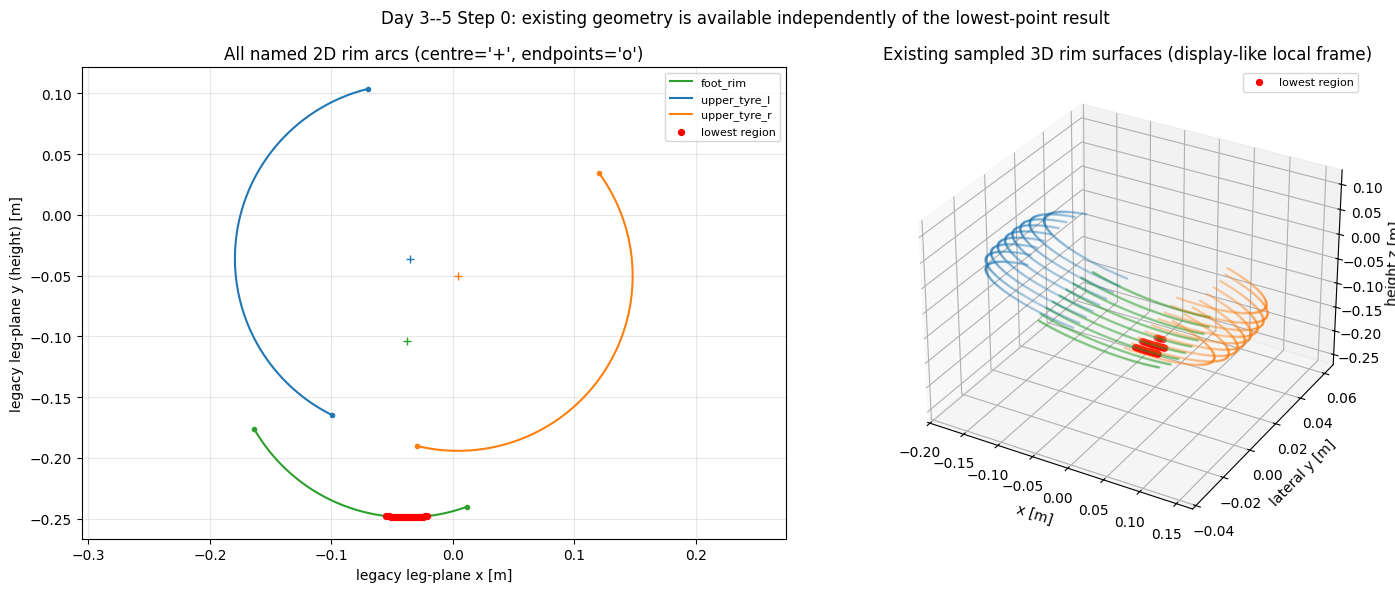

,case,height_axis,height_min_m,lowest_surface,semantic_state,candidate_points
0,legacy 2D,y,-0.248992,foot_rim,foot_rim,21
1,sampled 3D,z,-0.246101,foot_rim,foot_rim,49


In [11]:
fig = plot_leg_geometry_inventory(step0_inventory)
plt.show()

contact_2d = step0_inventory['contact_2d']
contact_3d = step0_inventory['contact_3d']
lowest_summary = pd.DataFrame([
    {
        'case': 'legacy 2D',
        'height_axis': 'y',
        'height_min_m': contact_2d['height_min'],
        'lowest_surface': contact_2d['lowest_surface_name'],
        'semantic_state': contact_2d['lowest_contact_state'],
        'candidate_points': contact_2d['number_of_contact_points'],
    },
    {
        'case': 'sampled 3D',
        'height_axis': 'z',
        'height_min_m': contact_3d['height_min'],
        'lowest_surface': contact_3d['lowest_surface_name'],
        'semantic_state': contact_3d['lowest_contact_state'],
        'candidate_points': contact_3d['number_of_contact_points'],
    },
])
display(lowest_summary.style.format({'height_min_m': '{:.6f}'}))

### 7.4 Step 0 結論與下一步邊界

**可以直接 reuse**

- `PlotLeg.forward(theta, beta)`：2D linkage points。
- `PlotLeg.leg_shape`：3 條 physical tyre outer arcs 的 center、arc endpoints 與完整 geometry。
- `sample_contact_geometry_points()` / `_3d()`：physical tyre samples，並沿用 ContactMap 的 F/L/R/N 分類；structural rims 已排除。
- `compute_ground_contact()` / `_pose_3d()`：lowest point / lowest region，可作 flat-ground regression oracle。
- `CorgiLegKinematics.forward_kinematics()` 與 `get_joint_positions()`：body-frame 3D 幾何基礎。

**進入 query 前必須補清楚**

1. Public `RimId` 維持只有 `FOOT / LEFT / RIGHT`；`non_contact_region (N)` 不加入 `RimId`，也不產生 `ContactCandidate`。
2. Legacy `rim_point(alpha, w)` 的 `alpha` 是 **degree**，Day 1–2 contract 是 **radian**；Step 4 建立唯一 global-alpha adapter。
3. `arc_angle_deg` 是 individual-arc polar angle，不等於 global rim `alpha`；需要 geometry sample → F/L/R/N → `RimId` / `alpha_rad` mapping。
4. 目前 3D contact-map helper 是 local/display-like frame；Step 2 必須以 `CorgiLegKinematics` 加 body pose，明確產生 `{W}` frame geometry。
5. 現有 lowest-region code 的確保留 `surface_records` / `surface_points`，所以 obstacle checking 能取得所有 rim geometry。
6. Bars/joints 可畫但尚未形成穩定 numeric collision API；Step 5 前需 expose linkage segments / joint circles。

因此 Step 0 已完成。以下進入 **Step 1：ground + single rectangle 的 2D Terrain Representation 與 surface identity**；此處仍不決定 contact、collision、ROLL 或 SWING。

## 8. Step 1 — 2D Terrain Representation

這一層只描述 world `x-z` plane 的地形：`+x` forward、`+z` upward。第一版允許 flat ground 或 ground + one rectangle。朝 `+x` 行進時，rectangle 的 `x_min` 是 front face，`x_max` 是 back face。

為避免和 Day 1–2 的 3D planning contract 混淆，package root 使用 `RectangleObstacle2D` / `TerrainProfile2D`；在 `terrain_2d` module 內仍是簡潔的 `RectangleObstacle` / `TerrainProfile`。

In [12]:
from legwheel.planners.hybrid import (
    RectangleObstacle2D,
    TerrainProfile2D,
    plot_terrain_profile_2d,
    terrain_surface_rows,
)

terrain_2d = TerrainProfile2D(
    ground_height_m=0.0,
    obstacles=[
        RectangleObstacle2D(
            obstacle_id='obstacle_0',
            x_min_m=0.40,
            x_max_m=0.60,
            height_m=0.05,
        )
    ],
)

print('Surface IDs:', terrain_2d.surface_ids)
print(f'Obstacle width: {terrain_2d.obstacle.width_m:.3f} m')

Surface IDs: ('ground', 'obstacle_0_top', 'obstacle_0_front', 'obstacle_0_back')
Obstacle width: 0.200 m


### 8.1 Surface identity 與幾何位置

`position_m` 的意義由 orientation 決定：horizontal surface 表示固定 `z`、span 是 `x` 範圍；vertical surface 表示固定 `x`、span 是 `z` 範圍。Ground 的 x span 是 `[-inf, +inf]`。

In [13]:
terrain_surface_table = pd.DataFrame(terrain_surface_rows(terrain_2d))
display(terrain_surface_table.style.format({
    'position_m': '{:.3f}',
    'span_min_m': '{:.3f}',
    'span_max_m': '{:.3f}',
}))

for surface_id in terrain_2d.surface_ids:
    surface = terrain_2d.surface_by_id(surface_id)
    print(f'{surface_id:24s} endpoints [x,z] = {surface.endpoints_xz_m.tolist()}')

,surface_id,kind,orientation,position_m,span_min_m,span_max_m
0,ground,ground,horizontal,0.000,-inf,inf
1,obstacle_0_top,obstacle_top,horizontal,0.050,0.400,0.600
2,obstacle_0_front,obstacle_front,vertical,0.400,0.000,0.050
3,obstacle_0_back,obstacle_back,vertical,0.600,0.000,0.050


ground                   endpoints [x,z] = [[-inf, 0.0], [inf, 0.0]]
obstacle_0_top           endpoints [x,z] = [[0.4, 0.05], [0.6, 0.05]]
obstacle_0_front         endpoints [x,z] = [[0.4, 0.0], [0.4, 0.05]]
obstacle_0_back          endpoints [x,z] = [[0.6, 0.0], [0.6, 0.05]]


### 8.2 Ground + rectangle visualization

圖中的 top/front/back 都是獨立 surface；rectangle 底面與 ground 重合，不另外建立隱藏的 bottom surface。

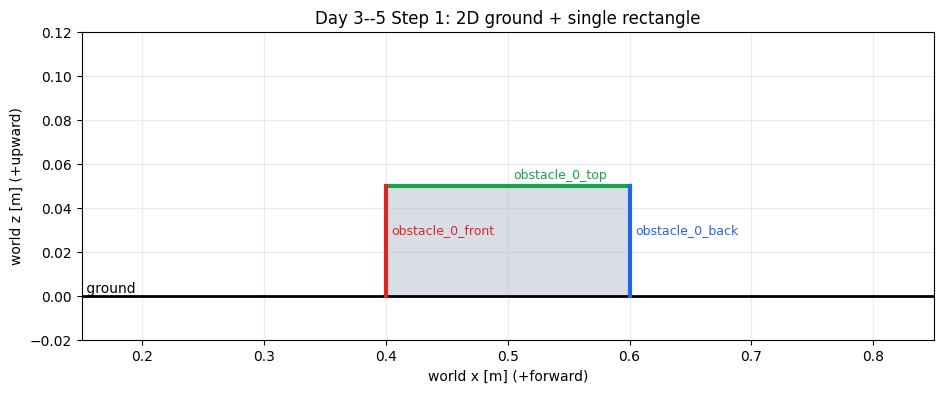

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_terrain_profile_2d(terrain_2d, ax=ax, x_limits_m=(0.15, 0.85))
plt.show()

### 8.3 Step 1 完成狀態

已完成：

- flat ground 與 ground + one rectangle 的 immutable 2D data contracts。
- `ground / obstacle_0_top / obstacle_0_front / obstacle_0_back` stable surface IDs。
- 可依 ID 取得 orientation、固定座標、有效 span 與 endpoints。
- rectangle 幾何與 surface identity visualization。
- unit tests 涵蓋 flat ground、surface geometry、invalid dimensions、single-obstacle scope、unknown ID 與 plotting。

尚未加入 point gap、penetration、contact candidate 或 collision 判斷。以下進入 **Step 2：把 legacy leg-plane geometry 經 hip pose 明確轉到相同的 world `x-z` frame**。

## 9. Step 2 — Hip frame ↔ World frame geometry transform

2D prototype 統一使用 `[x, z]`：`+x` forward、`+z` upward。Legacy `PlotLeg` 的 `(x, y_height)` 在 adapter 入口明確改名為 `(x_H, z_H)`，不再讓後續程式把 planar `y` 和 world lateral `y` 混用。

$$p_W = R_{WH}(\psi) p_H + p_{WH}, \qquad p_H = R_{WH}^{T}(p_W-p_{WH})$$

其中正的 hip pitch `ψ` 在 `x-z` 圖上是 counter-clockwise。`gamma` 不進入這個 2D rigid transform；3D ABAD geometry 仍由 `CorgiLegKinematics` 處理。

In [15]:
from legwheel.planners.hybrid import (
    HipPose2D,
    plot_leg_geometry_with_terrain_2d,
    sampled_leg_geometry_from_legacy_records,
    transform_points_hip_to_world,
    transform_points_world_to_hip,
)

step2_hip_x_world_m = 0.22
step2_hip_pitch_deg = 8.0
step2_visual_min_z_m = 0.01  # 僅用於安排驗證圖，不是 contact query

# 先以 z=0 套用 rotation，再選一個平移高度，讓完整 geometry 在圖中清楚位於 ground 上方。
pose_rotation_only = HipPose2D(
    [step2_hip_x_world_m, 0.0],
    np.deg2rad(step2_hip_pitch_deg),
)
geometry_rotation_only = sampled_leg_geometry_from_legacy_records(
    step0_inventory['contact_2d']['surface_records'],
    pose_rotation_only,
)
step2_hip_z_world_m = (
    step2_visual_min_z_m - geometry_rotation_only.points_world_xz_m[:, 1].min()
)
step2_hip_pose = HipPose2D(
    [step2_hip_x_world_m, step2_hip_z_world_m],
    np.deg2rad(step2_hip_pitch_deg),
)
step2_leg_geometry = sampled_leg_geometry_from_legacy_records(
    step0_inventory['contact_2d']['surface_records'],
    step2_hip_pose,
)

print(f'Hip position in W [x,z]: {step2_hip_pose.position_world_xz_m}')
print(f'Hip pitch W<-H: {step2_hip_pitch_deg:.1f} deg')
print(f'R_W_H:\n{step2_hip_pose.rotation_world_hip}')
print(f'Transformed rim samples: {len(step2_leg_geometry.points_world_xz_m)}')

Hip position in W [x,z]: [0.22       0.26324794]
Hip pitch W<-H: 8.0 deg
R_W_H:
[[ 0.99026807 -0.1391731 ]
 [ 0.1391731   0.99026807]]
Transformed rim samples: 363


### 9.1 H → W → H round-trip validation

以完整 rim sample set 做雙向轉換；誤差應只剩 floating-point rounding。

In [16]:
points_world = transform_points_hip_to_world(
    step2_leg_geometry.points_hip_xz_m,
    step2_hip_pose,
)
points_hip_recovered = transform_points_world_to_hip(points_world, step2_hip_pose)
round_trip_error_m = np.linalg.norm(
    points_hip_recovered - step2_leg_geometry.points_hip_xz_m,
    axis=1,
)
assert round_trip_error_m.max() < 1e-12

step2_summary = pd.DataFrame([
    {
        'frame/result': 'hip {H}',
        'x_min_m': step2_leg_geometry.points_hip_xz_m[:, 0].min(),
        'x_max_m': step2_leg_geometry.points_hip_xz_m[:, 0].max(),
        'z_min_m': step2_leg_geometry.points_hip_xz_m[:, 1].min(),
        'z_max_m': step2_leg_geometry.points_hip_xz_m[:, 1].max(),
    },
    {
        'frame/result': 'world {W}',
        'x_min_m': points_world[:, 0].min(),
        'x_max_m': points_world[:, 0].max(),
        'z_min_m': points_world[:, 1].min(),
        'z_max_m': points_world[:, 1].max(),
    },
])
display(step2_summary.style.format({column: '{:.6f}' for column in step2_summary if column.endswith('_m')}))
print(f'Max H→W→H round-trip error: {round_trip_error_m.max():.3e} m')
print(f'Clearance to obstacle front in x: {terrain_2d.obstacle.x_min_m - points_world[:, 0].max():.6f} m')

,frame/result,x_min_m,x_max_m,z_min_m,z_max_m
0,hip {H},-0.179399,0.147922,-0.248992,0.103712
1,world {W},0.045960,0.374907,0.010000,0.356269


Max H→W→H round-trip error: 6.206e-17 m
Clearance to obstacle front in x: 0.025093 m


### 9.2 Leg + rectangle world-frame validation

F/L/R/N 是 ContactMap semantic classification；rectangle surfaces 和所有 leg samples 現在位於同一個 world `x-z` frame。黑色 `×` 是 hip origin，紫色箭頭是 `+x_H`。圖中保留正的 obstacle-front x clearance，便於目視確認座標方向。

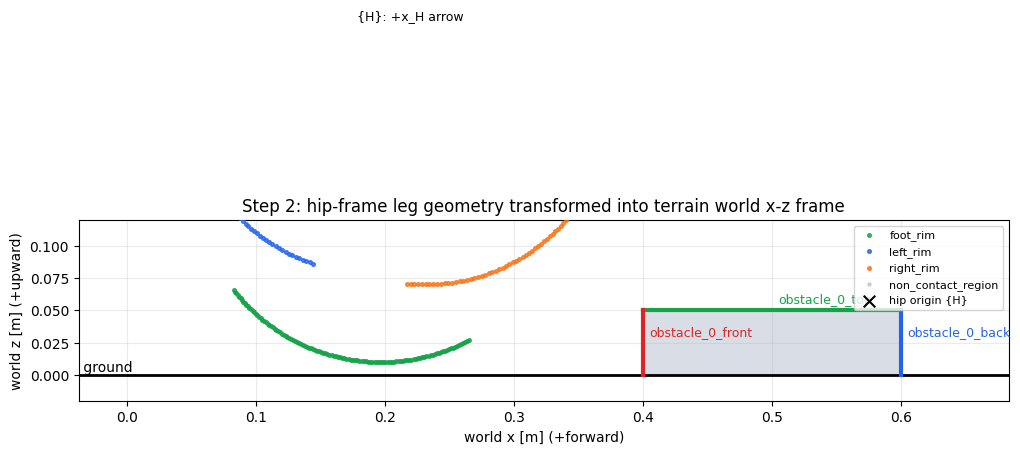

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_leg_geometry_with_terrain_2d(step2_leg_geometry, terrain_2d, ax=ax)
plt.show()

### 9.3 Step 2 完成狀態

已完成：

- immutable `HipPose2D(position_world_xz_m, pitch_world_hip_rad)`。
- vectorized `transform_points_hip_to_world()` 與 inverse transform。
- legacy `(x, y_height)` → explicit hip `(x_H, z_H)` rim-sample adapter。
- F/L/R/N geometry + rectangle 的 unified world-frame visualization。
- unit tests 驗證 `+90°` 方向、translation、round trip、invalid input、legacy adapter 與 overlay plot。

此步驟仍未做 terrain gap/contact/collision。以下進入 **Step 3：對任意 world-frame point 查詢 ground/top/front/back 的 relevant surface、signed gap 與 penetration**。

## 10. Step 3 — Point-to-terrain surface gap query

本步驟只回答 point 和每個 terrain surface 的客觀幾何關係，**不設定 contact tolerance、不產生 ContactCandidate、不做 F/L/R/N contact classification**。

Signed gap 統一沿 surface outward normal：

- ground / top：`z_point - z_surface`
- front（outward = `-x`）：`x_front - x_point`
- back（outward = `+x`）：`x_point - x_back`

負的 per-face gap 只表示位於該 supporting line 的 solid half-space，不能單獨視為 penetration；必須確認 point 真正在完整 ground/rectangle solid 裡。

In [18]:
from legwheel.planners.hybrid import (
    plot_point_terrain_query_2d,
    point_terrain_gap_rows,
    query_point_to_terrain_surfaces_2d,
)

step3_probe_points = {
    'above_ground': np.array([0.25, 0.02]),
    'before_front': np.array([0.39, 0.025]),
    'above_top': np.array([0.50, 0.07]),
    'inside_rectangle': np.array([0.41, 0.04]),
}
step3_queries = {
    name: query_point_to_terrain_surfaces_2d(point, terrain_2d)
    for name, point in step3_probe_points.items()
}

step3_query_summary = pd.DataFrame([
    {
        'probe': name,
        'point_x_m': query.point_world_xz_m[0],
        'point_z_m': query.point_world_xz_m[1],
        'nearest_relevant_surface': query.nearest_relevant_surface.surface_id,
        'nearest_distance_m': query.nearest_relevant_surface.euclidean_distance_m,
        'inside_terrain': query.point_inside_terrain,
        'penetrating_surfaces': ', '.join(
            gap.surface_id for gap in query.penetrating_surface_gaps
        ) or 'none',
    }
    for name, query in step3_queries.items()
])
display(step3_query_summary.style.format({
    'point_x_m': '{:.3f}',
    'point_z_m': '{:.3f}',
    'nearest_distance_m': '{:.6f}',
}))

,probe,point_x_m,point_z_m,nearest_relevant_surface,nearest_distance_m,inside_terrain,penetrating_surfaces
0,above_ground,0.250,0.020,ground,0.020000,False,none
1,before_front,0.390,0.025,obstacle_0_front,0.010000,False,none
2,above_top,0.500,0.070,obstacle_0_top,0.020000,False,none
3,inside_rectangle,0.410,0.040,obstacle_0_front,0.010000,True,"obstacle_0_top, obstacle_0_front, obstacle_0_back"


### 10.1 單一 point 對所有 surfaces 的完整結果

以下使用 obstacle front 前方的 point。可以看到 back face 的 signed gap 是負值，但因 point 不在 rectangle solid 裡，penetration 仍為零。這正是把 signed half-space gap 和 solid penetration 分開的理由。

In [19]:
step3_detail_query = step3_queries['before_front']
step3_detail_table = pd.DataFrame(point_terrain_gap_rows(step3_detail_query))
display(step3_detail_table.style.format({
    column: '{:.6f}'
    for column in step3_detail_table
    if column.endswith('_m')
}))

,surface_id,kind,signed_normal_gap_m,euclidean_distance_m,projection_within_span,is_occluded,is_relevant,inside_solid,penetration_depth_m,nearest_x_m,nearest_z_m
0,ground,ground,0.025000,0.025000,True,False,True,False,0.000000,0.390000,0.000000
1,obstacle_0_top,obstacle_top,-0.025000,0.026926,False,False,False,False,0.000000,0.400000,0.050000
2,obstacle_0_front,obstacle_front,0.010000,0.010000,True,False,True,False,0.000000,0.400000,0.025000
3,obstacle_0_back,obstacle_back,-0.210000,0.210000,True,False,True,False,0.000000,0.600000,0.025000


### 10.2 Nearest relevant surface visualization

紫色虛線連到實際 finite segment 上的 nearest point。紅色 query point 表示位於 terrain solid 內；黑色表示 free space。這只是 distance/relevance debug view，不代表 contact。

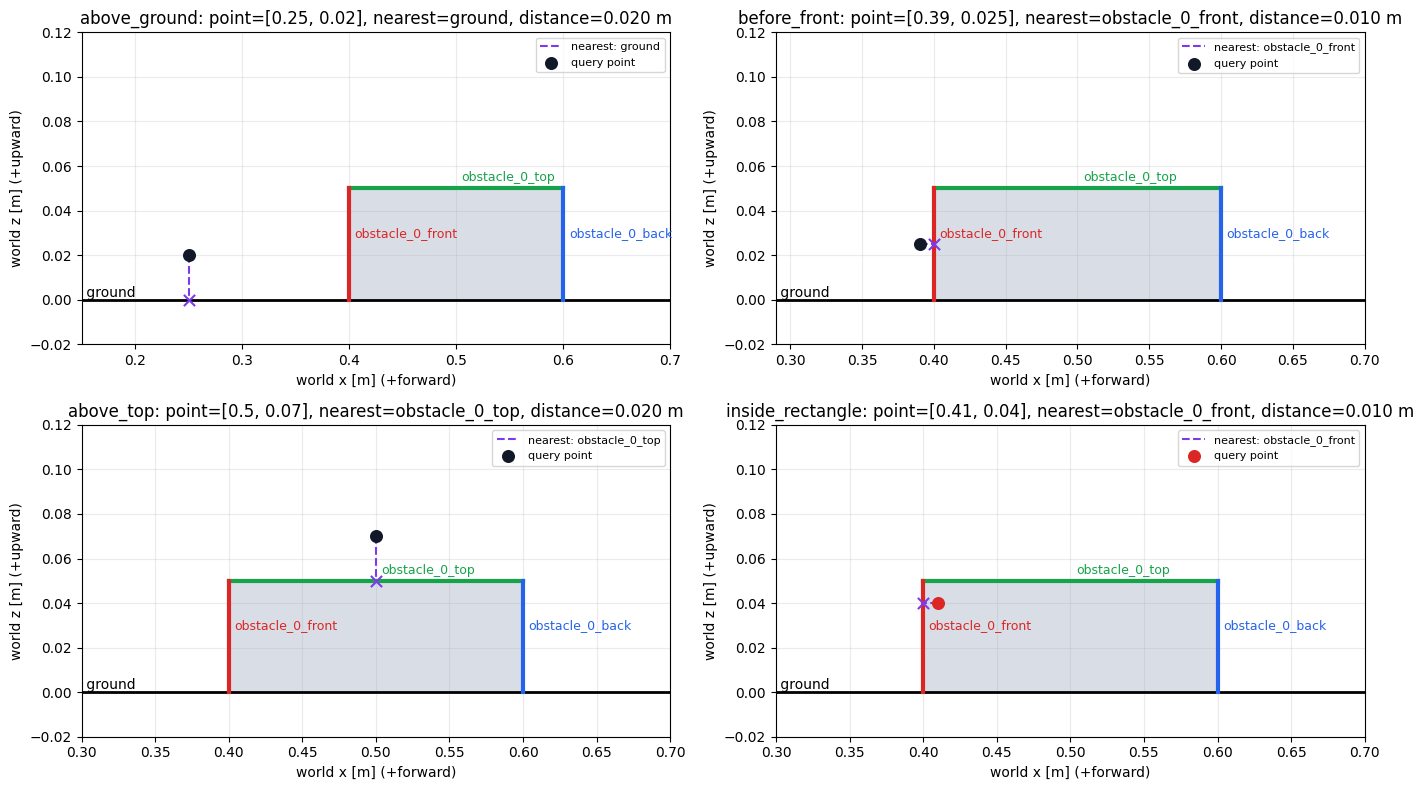

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, query) in zip(axes.flat, step3_queries.items()):
    plot_point_terrain_query_2d(query, terrain_2d, ax=ax)
    ax.set_title(f'{name}: ' + ax.get_title())
fig.tight_layout()
plt.show()

### 10.3 Step 3 完成狀態

已完成：

- point 對 ground/top/front/back 的 outward-normal signed gap。
- finite surface span projection、nearest point 與 Euclidean distance。
- `projection_within_span / is_occluded / is_relevant` 分離。
- ground 與 complete rectangle solid 的 penetration 判斷，避免由單一負 gap 誤判。
- 保留所有 surface results，另提供 nearest relevant surface；沒有刪成 contact state。
- unit tests 覆蓋 ground、top、front/back sign、occlusion、inside rectangle、span tolerance、invalid input 與 plotting。

尚未定義 contact tolerance，也未使用 rim classification。以下進入 **Step 4：將 F/L/R rim samples 送入 terrain query，依 contact tolerance 建立 ContactCandidate detection；N 不產生 candidate**。

## 11. Step 4 — Sampling-based ContactCandidate detection

這一步把 Step 2 的 world-frame tyre samples 逐點送進 Step 3 terrain query。只有 F/L/R sample 可以成為 candidate；N 即使剛好落在 terrain 上也會先被排除。

第一版判斷條件：

```text
surface is relevant
+ abs(signed normal gap) <= contact_tolerance
+ Euclidean distance to finite surface <= contact_tolerance
→ retain ContactCandidate2D
```

Sampling patch 內的所有 sample/surface pairs 都保留，不挑 active contact，也不合併成單一點。

### 11.1 Global rim alpha mapping

`arc_angle_deg` 是各自圓心的 polar angle；candidate 改用和 `LegModel.rim_point(alpha)` 一致的 global alpha：foot `[-40°, 40°]`、left `[-180°, -40°]`、right `[40°, 180°]`。Public candidate 儲存 radians。

In [21]:
from legwheel.planners.hybrid import (
    contact_candidate_rows,
    detect_contact_candidates_2d,
    plot_contact_candidates_2d,
)

step4_contact_tolerance_m = 1e-3
step4_records = step0_inventory['contact_2d']['surface_records']
step4_origin_geometry = sampled_leg_geometry_from_legacy_records(
    step4_records, HipPose2D([0.0, 0.0])
)
step4_valid_mask = np.array(step4_origin_geometry.contact_regions) != 'non_contact_region'
step4_valid_indices = np.flatnonzero(step4_valid_mask)
step4_lowest_index = step4_valid_indices[
    np.argmin(step4_origin_geometry.points_hip_xz_m[step4_valid_mask, 1])
]
step4_lowest_point_hip = step4_origin_geometry.points_hip_xz_m[step4_lowest_index]

# Case A: lowest valid tyre sample 放在 flat ground。
step4_flat_terrain = TerrainProfile2D()
step4_flat_geometry = sampled_leg_geometry_from_legacy_records(
    step4_records,
    HipPose2D([0.20, -step4_lowest_point_hip[1]]),
)

# Case B: 同一 lowest sample 放在 obstacle top 中央。
step4_top_pose = HipPose2D([
    0.50 - step4_lowest_point_hip[0],
    terrain_2d.obstacle.height_m - step4_lowest_point_hip[1],
])
step4_top_geometry = sampled_leg_geometry_from_legacy_records(step4_records, step4_top_pose)

# Case C: 在 top-contact pose 上再抬高 20 mm。
step4_air_geometry = sampled_leg_geometry_from_legacy_records(
    step4_records,
    HipPose2D(step4_top_pose.position_world_xz_m + np.array([0.0, 0.02])),
)

step4_cases = {
    'flat_ground': (step4_flat_geometry, step4_flat_terrain),
    'obstacle_top': (step4_top_geometry, terrain_2d),
    'airborne': (step4_air_geometry, terrain_2d),
}
step4_results = {
    name: detect_contact_candidates_2d(
        geometry, terrain, contact_tolerance_m=step4_contact_tolerance_m
    )
    for name, (geometry, terrain) in step4_cases.items()
}


### 11.2 Detection summary

`candidate_count` 是 sampling patch 中保留的 sample/surface pairs 數量，不是力學上的 contact 數量。

In [22]:
step4_summary = pd.DataFrame([
    {
        'case': name,
        'candidate_count': len(result.candidates),
        'rims': ', '.join(sorted({candidate.rim.value for candidate in result.candidates})) or 'none',
        'terrain_surfaces': ', '.join(result.candidate_surface_ids) or 'none',
        'evaluated_F_L_R_samples': result.evaluated_sample_count,
        'excluded_N_samples': result.excluded_non_contact_sample_count,
        'contact_tolerance_mm': result.contact_tolerance_m * 1e3,
    }
    for name, result in step4_results.items()
])
display(step4_summary.style.format({'contact_tolerance_mm': '{:.3f}'}))

step4_candidate_tables = []
for name, result in step4_results.items():
    for row in contact_candidate_rows(result):
        step4_candidate_tables.append({'case': name, **row})
step4_candidate_table = pd.DataFrame(step4_candidate_tables)
if not step4_candidate_table.empty:
    grouped = (
        step4_candidate_table
        .groupby(['case', 'rim', 'terrain_surface_id'], as_index=False)
        .agg(
            sample_count=('sample_index', 'count'),
            alpha_min_deg=('alpha_deg', 'min'),
            alpha_max_deg=('alpha_deg', 'max'),
            max_abs_gap_mm=('terrain_gap_m', lambda values: np.max(np.abs(values)) * 1e3),
        )
    )
    display(grouped.style.format({
        'alpha_min_deg': '{:.3f}',
        'alpha_max_deg': '{:.3f}',
        'max_abs_gap_mm': '{:.6f}',
    }))

,case,candidate_count,rims,terrain_surfaces,evaluated_F_L_R_samples,excluded_N_samples,contact_tolerance_mm
0,flat_ground,21,foot_rim,ground,361,2,1.000
1,obstacle_top,21,foot_rim,obstacle_0_top,361,2,1.000
2,airborne,0,none,none,361,2,1.000


,case,rim,terrain_surface_id,sample_count,alpha_min_deg,alpha_max_deg,max_abs_gap_mm
0,flat_ground,foot_rim,ground,21,13.333,26.667,0.980438
1,obstacle_top,foot_rim,obstacle_0_top,21,13.333,26.667,0.980438


### 11.3 Candidate records

以下顯示前 20 筆 sample-level candidates。`terrain_gap_m` 保留 signed gap，`surface_distance_m` 是到 finite terrain segment 的非負距離。

In [23]:
if step4_candidate_table.empty:
    print('No candidates detected.')
else:
    display(step4_candidate_table.head(20).style.format({
        'alpha_rad': '{:.6f}',
        'alpha_deg': '{:.3f}',
        'point_x_m': '{:.6f}',
        'point_z_m': '{:.6f}',
        'terrain_gap_m': '{:.6f}',
        'surface_distance_m': '{:.6f}',
    }))

,case,rim,alpha_rad,alpha_deg,point_x_m,point_z_m,terrain_surface_id,terrain_gap_m,surface_distance_m,edge_margin_rad,edge_margin_deg,raw_surface_name,sample_index
0,flat_ground,foot_rim,0.232711,13.333,0.145316,0.000980,ground,0.000980,0.000980,0.465421,26.666667,foot_rim,80
1,flat_ground,foot_rim,0.244346,14.000,0.146993,0.000794,ground,0.000794,0.000794,0.453786,26.000000,foot_rim,81
2,flat_ground,foot_rim,0.255982,14.667,0.148672,0.000628,ground,0.000628,0.000628,0.442150,25.333333,foot_rim,82
3,flat_ground,foot_rim,0.267617,15.333,0.150353,0.000481,ground,0.000481,0.000481,0.430515,24.666667,foot_rim,83
4,flat_ground,foot_rim,0.279253,16.000,0.152035,0.000353,ground,0.000353,0.000353,0.418879,24.000000,foot_rim,84
5,flat_ground,foot_rim,0.290888,16.667,0.153719,0.000245,ground,0.000245,0.000245,0.407243,23.333333,foot_rim,85
6,flat_ground,foot_rim,0.302524,17.333,0.155404,0.000157,ground,0.000157,0.000157,0.395608,22.666667,foot_rim,86
7,flat_ground,foot_rim,0.314159,18.000,0.157089,0.000088,ground,0.000088,0.000088,0.383972,22.000000,foot_rim,87
8,flat_ground,foot_rim,0.325795,18.667,0.158776,0.000039,ground,0.000039,0.000039,0.372337,21.333333,foot_rim,88
9,flat_ground,foot_rim,0.337430,19.333,0.160463,0.000010,ground,0.000010,0.000010,0.360701,20.666667,foot_rim,89


### 11.4 Candidate visualization

紅色空心圓是所有 retained candidates。Flat ground 與 obstacle top 應形成一小段 sampled contact patch；airborne 應為空。圖仍不選 active contact。

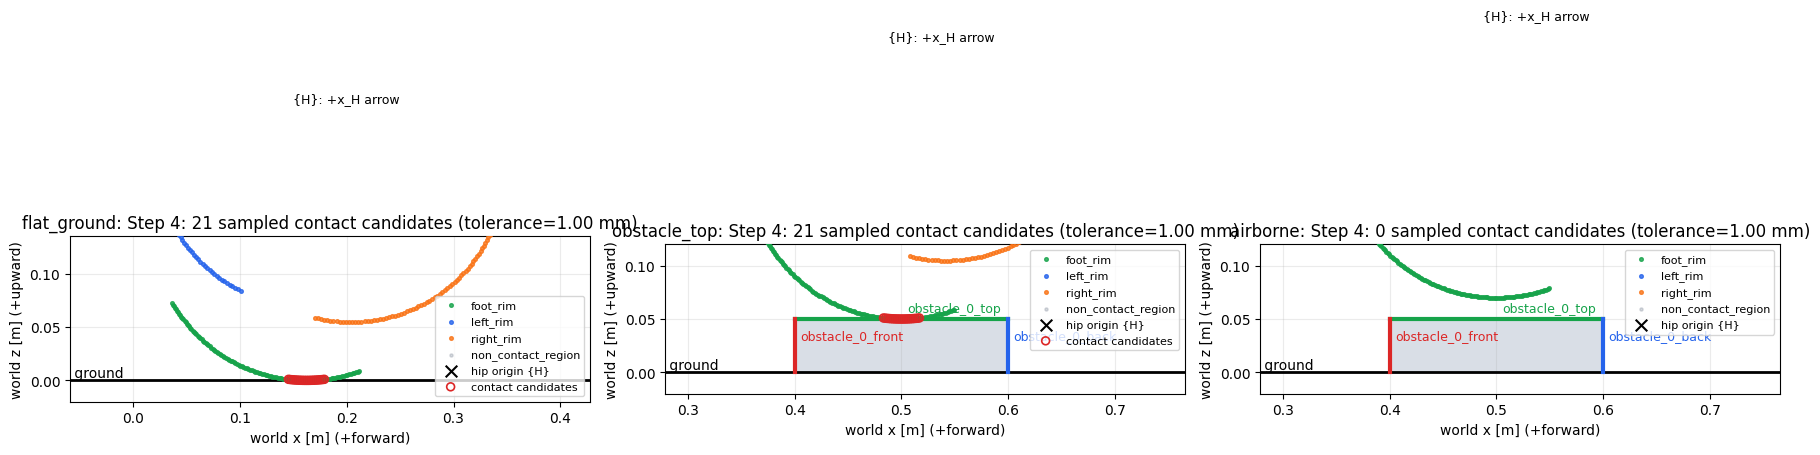

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (geometry, terrain)) in zip(axes, step4_cases.items()):
    plot_contact_candidates_2d(geometry, terrain, step4_results[name], ax=ax)
    ax.set_title(f'{name}: ' + ax.get_title())
fig.tight_layout()
plt.show()

### 11.5 Step 4 完成狀態

已完成：

- 3 條 physical tyre arcs 的 global `alpha_rad` mapping。
- F/L/R samples 對所有 relevant terrain surfaces 的 tolerance detection。
- N/open-gap endpoints 永遠不產生 candidate。
- Candidate 保存 rim、alpha、world point、terrain projection、surface ID、signed gap、distance 與 raw sample identity。
- 保留 obstacle corner 的 multiple surface candidates，不做 active-contact selection。
- unit tests 覆蓋 alpha、flat ground、obstacle top、occluded ground、airborne、N filtering、corner multiple candidates 與 plotting。

這裡使用獨立的 `ContactCandidate2D`，因為既有 3D public `ContactCandidate` 還要求 `edge_margin` 與 `collision_free`，目前不能填假資料。下一步是 **Step 5：whole-leg collision/interference checking**。

## 12. Task 6 — Rectangle vertical-face collision detection

Task 5 的 ContactCandidate 是幾何鄰近資訊；本步驟另外偵測 rectangle 的 front/back vertical face。vertical face 是 blocking geometry，不會被當成可走或可滾的 support contact。

特別測試：同一個 leg 同時保留 ground contact，且另一個 rim sample 撞到 obstacle front。

In [25]:
from legwheel.planners.hybrid import (
    detect_rectangle_vertical_face_collisions_2d,
    vertical_face_collision_rows,
)

step6_records = step0_inventory['contact_2d']['surface_records']
step6_origin = sampled_leg_geometry_from_legacy_records(step6_records, HipPose2D([0.0, 0.0]))
step6_valid = np.array(step6_origin.contact_regions) != 'non_contact_region'
step6_lowest = np.flatnonzero(step6_valid)[np.argmin(step6_origin.points_hip_xz_m[step6_valid, 1])]
step6_lowest_point = step6_origin.points_hip_xz_m[step6_lowest]
step6_geometry = sampled_leg_geometry_from_legacy_records(
    step6_records,
    HipPose2D([-step6_lowest_point[0], -step6_lowest_point[1] + 0.0002]),
)
step6_world_points = step6_geometry.points_world_xz_m
step6_front_candidates = np.flatnonzero(
    step6_valid & (step6_world_points[:, 0] > 0.02) & (step6_world_points[:, 1] > 0.01)
)
step6_front_index = step6_front_candidates[np.argmax(step6_world_points[step6_front_candidates, 0])]
step6_front_point = step6_world_points[step6_front_index]
step6_obstacle = RectangleObstacle2D(
    'step6_box',
    float(step6_front_point[0] - 0.0005),
    float(step6_front_point[0] + 0.10),
    float(step6_front_point[1] + 0.01),
)
step6_terrain = TerrainProfile2D(obstacles=[step6_obstacle])
step6_contacts = detect_contact_candidates_2d(step6_geometry, step6_terrain, contact_tolerance_m=1e-3)
step6_collisions = detect_rectangle_vertical_face_collisions_2d(
    step6_geometry, step6_terrain, collision_tolerance_m=1e-3
)
step6_contact_table = pd.DataFrame(contact_candidate_rows(step6_contacts))
step6_collision_table = pd.DataFrame(vertical_face_collision_rows(step6_collisions))


In [26]:
step6_summary = pd.DataFrame([
    {
        'ground_contact_exists': bool((step6_contact_table['terrain_surface_id'] == 'ground').any()) if not step6_contact_table.empty else False,
        'contact_candidate_count': len(step6_contacts.candidates),
        'vertical_face_collision': step6_collisions.has_collision,
        'collision_surface_ids': ', '.join(step6_collisions.collision_surface_ids) or 'none',
        'collision_count': len(step6_collisions.collisions),
        'excluded_N_samples': step6_collisions.excluded_non_contact_sample_count,
    }
])
display(step6_summary)
display(step6_collision_table)

,ground_contact_exists,contact_candidate_count,vertical_face_collision,collision_surface_ids,collision_count,excluded_N_samples
0,True,30,True,step6_box_front,11,2


,rim,alpha_rad,alpha_deg,point_x_m,point_z_m,terrain_surface_id,signed_normal_gap_m,surface_distance_m,penetration_depth_m,raw_surface_name,sample_index
0,right_rim,2.367830,135.666667,0.184374,0.178711,step6_box_front,0.000897,0.000897,0.000000,upper_tyre_r,324
1,right_rim,2.388192,136.833333,0.184752,0.181615,step6_box_front,0.000520,0.000520,0.000000,upper_tyre_r,325
2,right_rim,2.408554,138.000000,0.185071,0.184526,step6_box_front,0.000201,0.000201,0.000000,upper_tyre_r,326
3,right_rim,2.428917,139.166667,0.185330,0.187442,step6_box_front,-0.000058,0.000058,0.000058,upper_tyre_r,327
4,right_rim,2.449279,140.333333,0.185530,0.190363,step6_box_front,-0.000258,0.000258,0.000258,upper_tyre_r,328
5,right_rim,2.469641,141.500000,0.185670,0.193288,step6_box_front,-0.000398,0.000398,0.000398,upper_tyre_r,329
6,right_rim,2.490003,142.666667,0.185751,0.196215,step6_box_front,-0.000479,0.000479,0.000479,upper_tyre_r,330
7,right_rim,2.510365,143.833333,0.185772,0.199143,step6_box_front,-0.000500,0.000500,0.000500,upper_tyre_r,331
8,right_rim,2.530727,145.000000,0.185733,0.202071,step6_box_front,-0.000461,0.000461,0.000461,upper_tyre_r,332
9,right_rim,2.551090,146.166667,0.185635,0.204997,step6_box_front,-0.000363,0.000363,0.000363,upper_tyre_r,333


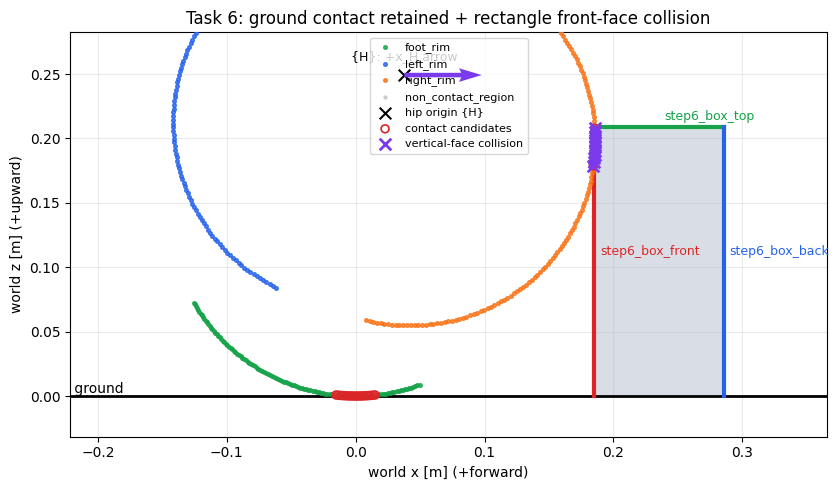

In [27]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_contact_candidates_2d(step6_geometry, step6_terrain, step6_contacts, ax=ax)
if step6_collisions.collisions:
    collision_points = np.array([item.point_world_xz_m for item in step6_collisions.collisions])
    ax.scatter(collision_points[:, 0], collision_points[:, 1], marker='x', s=70, c='#7c3aed', linewidths=2.0, label='vertical-face collision', zorder=10)
    ax.legend(fontsize=8, loc='best')
ax.set_title('Task 6: ground contact retained + rectangle front-face collision')
fig.tight_layout()
plt.show()

### 12.1 Task 6 完成狀態

已完成：

- front/back vertical face 的有限 span collision detection。
- N samples 排除，不會被視為 collision。
- ground contact 與 obstacle front collision 可同時存在。
- vertical face collision 以獨立 `VerticalFaceCollision2D` 回傳，不混入 locomotion support contact。

下一步可進入 whole-leg collision/interference 或 active-contact selection。

## 13. Task 7 — Unified `query_contact()`

將 Task 5 的 support candidates 與 Task 6 的 rectangle vertical-face collisions 包成單一 single-configuration query。這裡只回傳幾何結果，不選 active contact，也不決定 ROLL / SWING。

In [28]:
from legwheel.planners.hybrid import query_contact

step7_result = query_contact(
    step6_geometry,
    step6_terrain,
    contact_tolerance_m=1e-3,
    collision_tolerance_m=1e-3,
)
step7_summary = pd.DataFrame([{
    'candidate_count': len(step7_result.candidates),
    'collision_count': len(step7_result.collisions),
    'candidate_surface_ids': ', '.join(step7_result.candidate_surface_ids) or 'none',
    'collision_surface_ids': ', '.join(step7_result.collision_surface_ids) or 'none',
    'has_contact_candidates': step7_result.has_contact_candidates,
    'has_collisions': step7_result.has_collisions,
    'evaluated_samples': step7_result.evaluated_sample_count,
    'excluded_N_samples': step7_result.excluded_non_contact_sample_count,
}])
display(step7_summary)
display(pd.DataFrame(contact_candidate_rows(step6_contacts)).head(10))
display(pd.DataFrame(vertical_face_collision_rows(step6_collisions)).head(10))

,candidate_count,collision_count,candidate_surface_ids,collision_surface_ids,has_contact_candidates,has_collisions,evaluated_samples,excluded_N_samples
0,30,11,"ground, step6_box_front",step6_box_front,True,True,361,2


,rim,alpha_rad,alpha_deg,point_x_m,point_z_m,terrain_surface_id,terrain_gap_m,surface_distance_m,edge_margin_rad,edge_margin_deg,raw_surface_name,sample_index
0,foot_rim,0.244346,14.000000,-0.015157,0.000994,ground,0.000994,0.000994,0.453786,26.000000,foot_rim,81
1,foot_rim,0.255982,14.666667,-0.013478,0.000828,ground,0.000828,0.000828,0.442150,25.333333,foot_rim,82
2,foot_rim,0.267617,15.333333,-0.011797,0.000681,ground,0.000681,0.000681,0.430515,24.666667,foot_rim,83
3,foot_rim,0.279253,16.000000,-0.010115,0.000553,ground,0.000553,0.000553,0.418879,24.000000,foot_rim,84
4,foot_rim,0.290888,16.666667,-0.008431,0.000445,ground,0.000445,0.000445,0.407243,23.333333,foot_rim,85
5,foot_rim,0.302524,17.333333,-0.006746,0.000357,ground,0.000357,0.000357,0.395608,22.666667,foot_rim,86
6,foot_rim,0.314159,18.000000,-0.005060,0.000288,ground,0.000288,0.000288,0.383972,22.000000,foot_rim,87
7,foot_rim,0.325795,18.666667,-0.003374,0.000239,ground,0.000239,0.000239,0.372337,21.333333,foot_rim,88
8,foot_rim,0.337430,19.333333,-0.001687,0.000210,ground,0.000210,0.000210,0.360701,20.666667,foot_rim,89
9,foot_rim,0.349066,20.000000,0.000000,0.000200,ground,0.000200,0.000200,0.349066,20.000000,foot_rim,90


,rim,alpha_rad,alpha_deg,point_x_m,point_z_m,terrain_surface_id,signed_normal_gap_m,surface_distance_m,penetration_depth_m,raw_surface_name,sample_index
0,right_rim,2.367830,135.666667,0.184374,0.178711,step6_box_front,0.000897,0.000897,0.000000,upper_tyre_r,324
1,right_rim,2.388192,136.833333,0.184752,0.181615,step6_box_front,0.000520,0.000520,0.000000,upper_tyre_r,325
2,right_rim,2.408554,138.000000,0.185071,0.184526,step6_box_front,0.000201,0.000201,0.000000,upper_tyre_r,326
3,right_rim,2.428917,139.166667,0.185330,0.187442,step6_box_front,-0.000058,0.000058,0.000058,upper_tyre_r,327
4,right_rim,2.449279,140.333333,0.185530,0.190363,step6_box_front,-0.000258,0.000258,0.000258,upper_tyre_r,328
5,right_rim,2.469641,141.500000,0.185670,0.193288,step6_box_front,-0.000398,0.000398,0.000398,upper_tyre_r,329
6,right_rim,2.490003,142.666667,0.185751,0.196215,step6_box_front,-0.000479,0.000479,0.000479,upper_tyre_r,330
7,right_rim,2.510365,143.833333,0.185772,0.199143,step6_box_front,-0.000500,0.000500,0.000500,upper_tyre_r,331
8,right_rim,2.530727,145.000000,0.185733,0.202071,step6_box_front,-0.000461,0.000461,0.000461,upper_tyre_r,332
9,right_rim,2.551090,146.166667,0.185635,0.204997,step6_box_front,-0.000363,0.000363,0.000363,upper_tyre_r,333


### 13.1 Task 7 完成狀態

`query_contact()` 現在回傳：

- `result.candidates`：靠近 terrain surface 的 rim sample candidates。
- `result.collisions`：靠近 rectangle front/back vertical face 的 blocking hits。

兩個集合都完整保留，不會被壓成單一 contact；active-contact selection 與 gait mode 留給後續步驟。

## 14. Task 8 — Rim edge / transition margin

對每個 ContactCandidate 計算 global `alpha_rad` 到該 rim arc 最近邊界的距離。這是 deterministic metadata，不會刪除 candidate，也不會決定 active contact。

In [29]:
step8_candidate_table = pd.DataFrame(contact_candidate_rows(step7_result))
if step8_candidate_table.empty:
    step8_summary = pd.DataFrame()
else:
    step8_summary = (step8_candidate_table.groupby(['rim', 'terrain_surface_id'], as_index=False)
        .agg(candidate_count=('sample_index', 'size'), min_edge_margin_deg=('edge_margin_deg', 'min'), max_edge_margin_deg=('edge_margin_deg', 'max')))
display(step8_summary)
display(step8_candidate_table[['rim', 'alpha_deg', 'edge_margin_deg', 'terrain_surface_id', 'sample_index']].head(20))

,rim,terrain_surface_id,candidate_count,min_edge_margin_deg,max_edge_margin_deg
0,foot_rim,ground,19,14.000000,26.000000
1,right_rim,step6_box_front,11,32.666667,44.333333


,rim,alpha_deg,edge_margin_deg,terrain_surface_id,sample_index
0,foot_rim,14.000000,26.000000,ground,81
1,foot_rim,14.666667,25.333333,ground,82
2,foot_rim,15.333333,24.666667,ground,83
3,foot_rim,16.000000,24.000000,ground,84
4,foot_rim,16.666667,23.333333,ground,85
5,foot_rim,17.333333,22.666667,ground,86
6,foot_rim,18.000000,22.000000,ground,87
7,foot_rim,18.666667,21.333333,ground,88
8,foot_rim,19.333333,20.666667,ground,89
9,foot_rim,20.000000,20.000000,ground,90


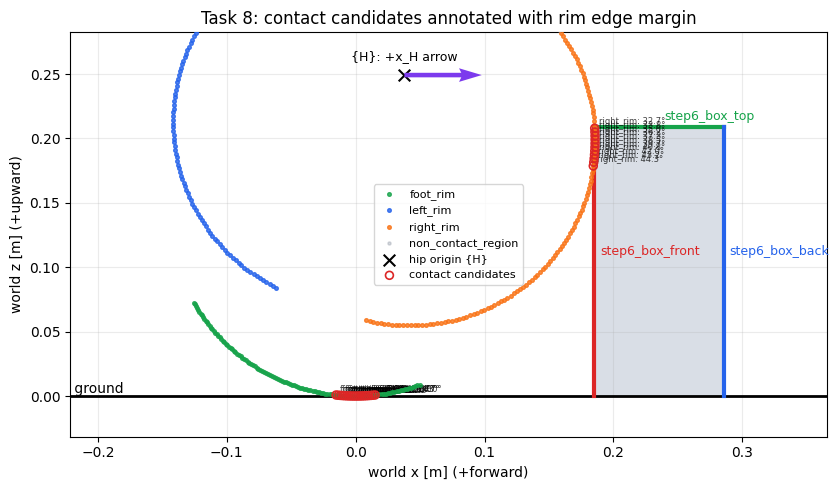

In [30]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_contact_candidates_2d(step6_geometry, step6_terrain, step7_result, ax=ax)
for candidate in step7_result.candidates:
    point = candidate.point_world_xz_m
    ax.annotate(f"{candidate.rim.value}: {np.rad2deg(candidate.edge_margin_rad):.1f}°", (point[0], point[1]), xytext=(3, 3), textcoords='offset points', fontsize=6, alpha=0.75)
ax.set_title('Task 8: contact candidates annotated with rim edge margin')
fig.tight_layout()
plt.show()

### 14.1 Task 8 完成狀態

每個 candidate 現在都保留 `edge_margin_rad` / `edge_margin_deg`。margin 越小代表越接近相鄰 rim 的 transition boundary；margin 越大代表 contact 位於該 rim arc 的中間。

## 15. Task 9 — Preserve multiple contacts

這裡建立兩個不同 rim 同時接觸 ground 的 configuration，確認 `query_contact()` 保留所有 candidates，不會在 query 階段強制選成單一 contact。

In [31]:
from legwheel.planners.hybrid import HipPose2D, SampledLegGeometry2D

step9_geometry = SampledLegGeometry2D(
    points_hip_xz_m=np.array([[0.0, 0.0], [0.2, 0.0], [0.1, 0.02]]),
    surface_names=['foot_rim', 'upper_tyre_r', 'upper_tyre_l'],
    contact_regions=['foot_rim', 'right_rim', 'left_rim'],
    arc_angles_deg=np.array([0.0, 0.0, 0.0]),
    alpha_rad=np.deg2rad(np.array([0.0, 90.0, -90.0])),
    hip_pose=HipPose2D([0.0, 0.0]),
)
step9_result = query_contact(step9_geometry, TerrainProfile2D(), contact_tolerance_m=1e-3)
step9_table = pd.DataFrame(contact_candidate_rows(step9_result))
step9_summary = pd.DataFrame([{
    'candidate_count': len(step9_result.candidates),
    'candidate_rims': ', '.join(sorted({item.rim.value for item in step9_result.candidates})),
    'candidate_surfaces': ', '.join(step9_result.candidate_surface_ids),
    'collision_count': len(step9_result.collisions),
    'multiple_contacts_preserved': len(step9_result.candidates) == 2,
}])
display(step9_summary)
display(step9_table)

,candidate_count,candidate_rims,candidate_surfaces,collision_count,multiple_contacts_preserved
0,2,"foot_rim, right_rim",ground,0,True


,rim,alpha_rad,alpha_deg,point_x_m,point_z_m,terrain_surface_id,terrain_gap_m,surface_distance_m,edge_margin_rad,edge_margin_deg,raw_surface_name,sample_index
0,foot_rim,0.000000,0.0,0.0,0.0,ground,0.0,0.0,0.698132,40.0,foot_rim,0
1,right_rim,1.570796,90.0,0.2,0.0,ground,0.0,0.0,0.872665,50.0,upper_tyre_r,1


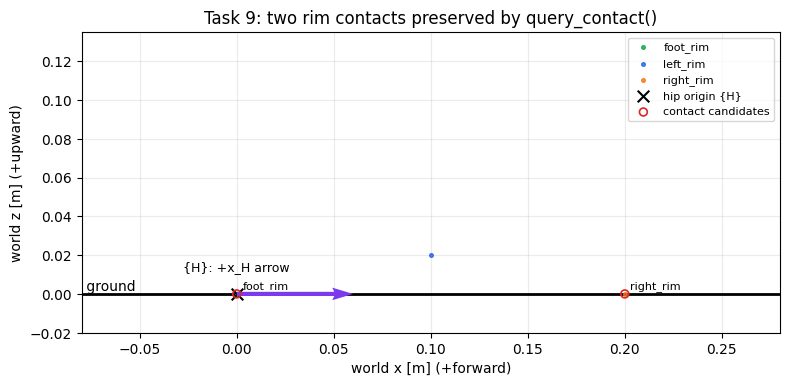

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_contact_candidates_2d(step9_geometry, TerrainProfile2D(), step9_result, ax=ax)
for candidate in step9_result.candidates:
    point = candidate.point_world_xz_m
    ax.annotate(candidate.rim.value, (point[0], point[1]), xytext=(4, 4), textcoords='offset points', fontsize=8)
ax.set_title('Task 9: two rim contacts preserved by query_contact()')
fig.tight_layout()
plt.show()

### 15.1 Task 9 完成狀態

`query_contact()` 保留多個 rim / surface candidates；它只回傳完整幾何候選集合，不在這一層執行 active-contact selection。

## 16. Task 10 — Day 3–5 visualization and regression suite

這裡固定文件中的 A–G cases，並使用同一個 `plot_contact_query_2d()` 顯示 leg/rim、terrain、candidate、collision、surface ID、alpha、gap 與 edge margin。

In [33]:
from legwheel.planners.hybrid import (
    HipPose2D, RectangleObstacle2D, SampledLegGeometry2D, TerrainProfile2D,
    plot_contact_query_2d, query_contact,
)

step10_flat_geometry = SampledLegGeometry2D(
    points_hip_xz_m=np.array([[0.0, 0.0]]),
    surface_names=['foot_rim'], contact_regions=['foot_rim'],
    arc_angles_deg=np.array([0.0]), alpha_rad=np.array([0.0]),
    hip_pose=HipPose2D([0.0, 0.0]),
)
step10_transition_geometry = SampledLegGeometry2D(
    points_hip_xz_m=np.array([[0.0, 0.0]]),
    surface_names=['foot_rim'], contact_regions=['foot_rim'],
    arc_angles_deg=np.array([0.0]), alpha_rad=np.array([np.deg2rad(39.5)]),
    hip_pose=HipPose2D([0.0, 0.0]),
)
step10_approach_geometry = SampledLegGeometry2D(
    points_hip_xz_m=np.array([[0.0, 0.0], [0.39, 0.025]]),
    surface_names=['foot_rim', 'upper_tyre_r'], contact_regions=['foot_rim', 'right_rim'],
    arc_angles_deg=np.array([0.0, 0.0]), alpha_rad=np.array([0.0, 1.0]),
    hip_pose=HipPose2D([0.0, 0.0]),
)
step10_terrain = TerrainProfile2D(obstacles=[RectangleObstacle2D('step10_box', 0.4, 0.6, 0.05)])
step10_cases = {
    'A flat ground': (step10_flat_geometry, TerrainProfile2D()),
    'B approaching obstacle': (step10_approach_geometry, step10_terrain),
    'C vertical-face interference': (step6_geometry, step6_terrain),
    'D obstacle top': (step4_top_geometry, terrain_2d),
    'E no contact': (step4_air_geometry, terrain_2d),
    'F near transition': (step10_transition_geometry, TerrainProfile2D()),
    'G multiple contact': (step9_geometry, TerrainProfile2D()),
}
step10_results = {name: query_contact(geometry, terrain) for name, (geometry, terrain) in step10_cases.items()}
step10_summary_rows = []
for name, result in step10_results.items():
    if name.startswith('A'):
        passed = 'ground' in result.candidate_surface_ids and not result.has_collisions
    elif name.startswith('B'):
        passed = 'ground' in result.candidate_surface_ids and not result.has_collisions
    elif name.startswith('C'):
        passed = 'ground' in result.candidate_surface_ids and 'step6_box_front' in result.collision_surface_ids
    elif name.startswith('D'):
        passed = result.candidate_surface_ids == ('obstacle_0_top',) and not result.has_collisions
    elif name.startswith('E'):
        passed = not result.candidates and not result.collisions
    elif name.startswith('F'):
        passed = bool(result.candidates) and np.rad2deg(result.candidates[0].edge_margin_rad) < 1.0
    else:
        passed = len(result.candidates) > 1
    step10_summary_rows.append({
        'case': name, 'candidates': len(result.candidates),
        'candidate_surfaces': ', '.join(result.candidate_surface_ids) or 'none',
        'collisions': len(result.collisions),
        'collision_surfaces': ', '.join(result.collision_surface_ids) or 'none',
        'pass': passed,
    })
step10_summary = pd.DataFrame(step10_summary_rows)
display(step10_summary)

,case,candidates,candidate_surfaces,collisions,collision_surfaces,pass
0,A flat ground,1,ground,0,none,True
1,B approaching obstacle,1,ground,0,none,True
2,C vertical-face interference,30,"ground, step6_box_front",11,step6_box_front,True
3,D obstacle top,21,obstacle_0_top,0,none,True
4,E no contact,0,none,0,none,True
5,F near transition,1,ground,0,none,True
6,G multiple contact,2,ground,0,none,True


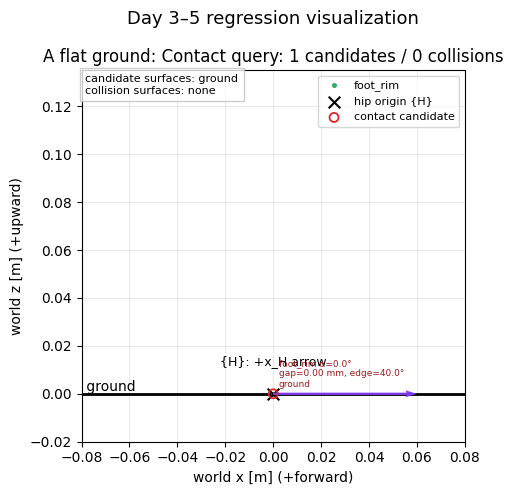

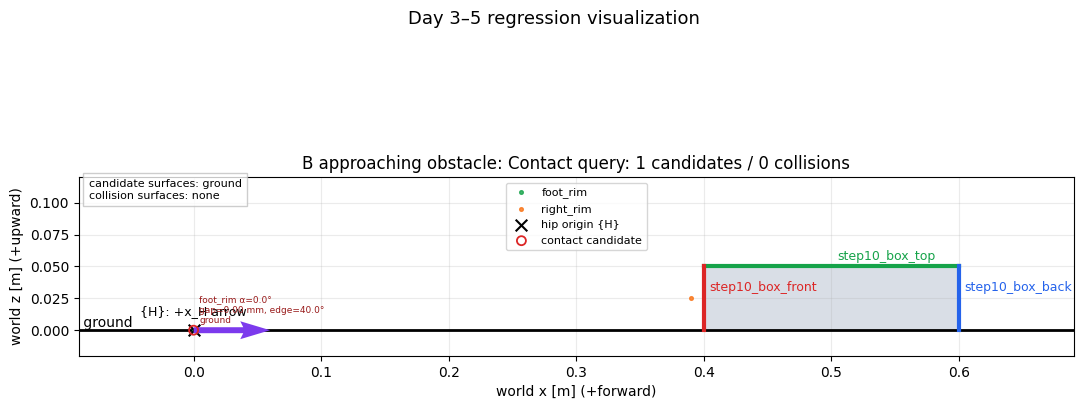

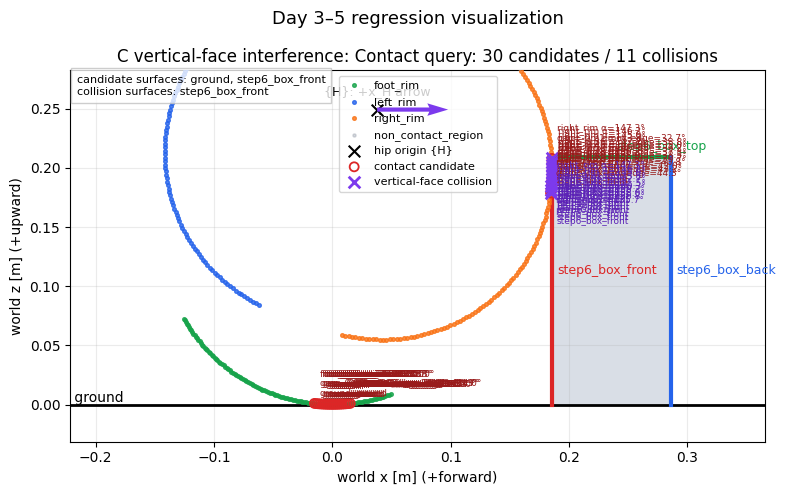

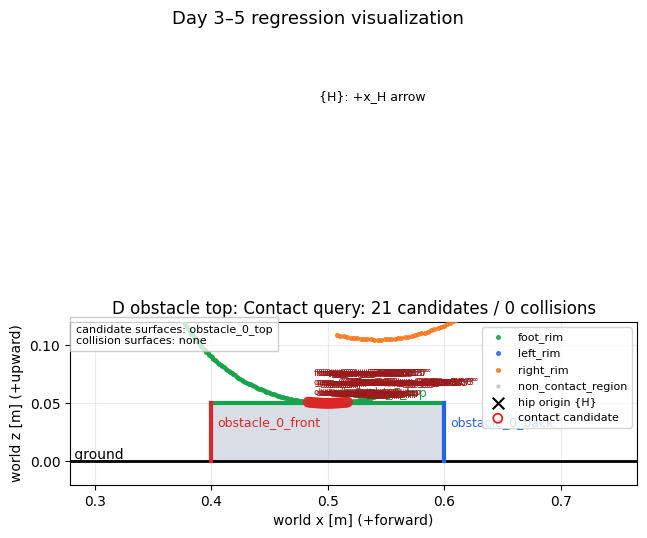

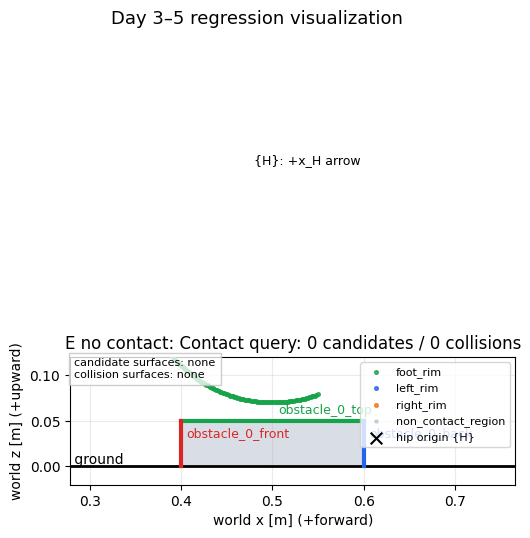

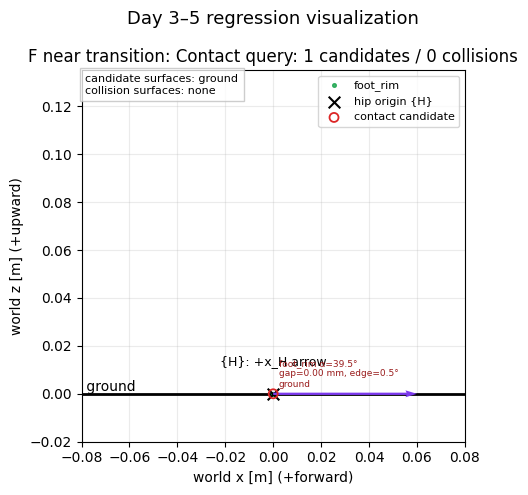

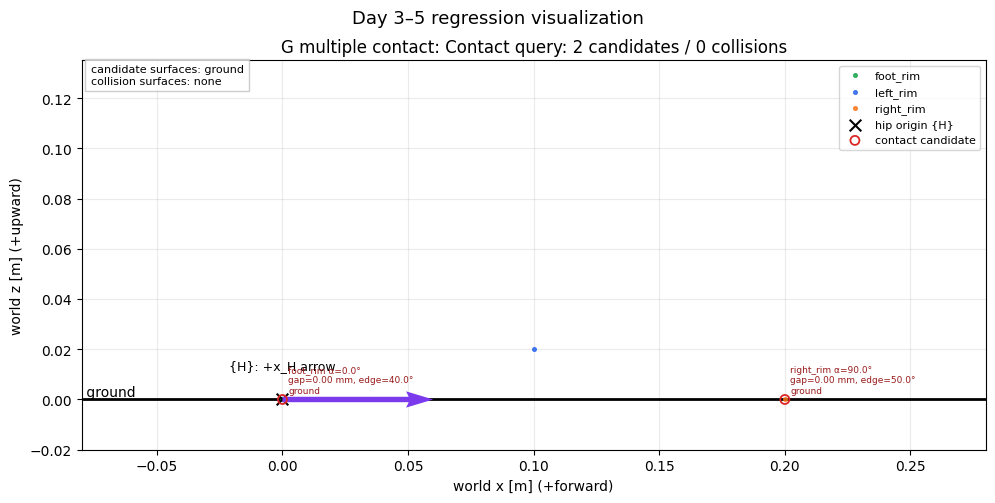

In [34]:
for name, (geometry, terrain) in step10_cases.items():
    fig, ax = plt.subplots(figsize=(11, 5))
    plot_contact_query_2d(geometry, terrain, step10_results[name], ax=ax, annotate=True)
    ax.set_title(f'{name}: ' + ax.get_title())
    fig.suptitle('Day 3–5 regression visualization', fontsize=13)
    fig.tight_layout()
    plt.show()

### 16.1 Task 10 完成狀態

已建立完整 query visualization，並固定 Day 3–5 A–G regression cases。每個案例同時檢查 candidates、vertical-face collisions、surface IDs、multiple contacts 與 transition margin。